# $N_{\rm{eff}}$ and LINX

In [1]:
%load_ext autoreload

In [2]:
%autoreload

import matplotlib.pyplot as plt

import sys
sys.path.append('..')

import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

import equinox as eqx

from scipy.interpolate import interp1d
# Load plot settings

from plot_params import params
pylab.rcParams.update(params)

cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

%matplotlib inline

The float input to the LINX `BackgroundModel()` is not $\Delta N_{\rm{eff}}$.  It is a parameter we call `Delta_Neff_init`, which is defined by
$$
\Delta N_{\mathrm{eff},i} = \frac87\left(\frac{11}{4}\right)^{4/3}\frac{\rho_{\xi,i}}{\rho_{\gamma,i}},
$$
where $\rho_{\gamma,i}$ is the _initial_ photon energy density and $\rho_{\xi,i}$ is the _initial_ energy density of some inert, relativistic species $\xi$.  Because of non-instantaneous neutrino decoupling during electron-positron annihilation it is difficult to know a quantity like $\Delta N_{\rm{eff}}$ without first running the thermodynamics module; as this is the most expensive part of a LINX solve, we have the user specify `Delta_Neff_init` instead.

In $\Lambda$CDM, `Delta_Neff_init` maps to $N_{\rm{eff}}$ in a predictable way:

In [3]:
from linx.background import BackgroundModel
import linx.thermo as th
import linx.const as cn 

In [4]:
# Initialize the class. 
get_thermodynamics = BackgroundModel() 

# Pick some values for delta_neff_init
delta_neff_init_vals = jnp.linspace(-3.,3.,num=10)

# make a function that returns N_eff
def get_Neff(delta_neff_init):
    _, _, _, _, _, _, Neff_vec = get_thermodynamics(jnp.asarray(delta_neff_init)) 
    return Neff_vec[-1]

In [5]:
# for light thermodynamics calculation on personal hardware,
# serial evaluation tends to be faster than vmapping
Neffs = jnp.stack([get_Neff(jnp.asarray(v)) for v in delta_neff_init_vals])

`\         /´  ||||        ||||  |||||     ||||  ||||   ||||
 /\_______/\   ||||        ||||  |||||||   ||||   |||| ||||
 ) __` ´__ (   ||||        ||||  |||| |||| ||||    |||||||
/  `-|_|-´  \  ||||        ||||  ||||  |||| |||    ||||||| 
/   (_x_)   \  ||||||||||  ||||  ||||   |||||||   |||| ||||
  )  `-´  (    ||||||||||  ||||  ||||    ||||||  ||||   ||||
 
Compiling thermodynamics model...


Text(0, 0.5, '$N_{\\rm{eff}}$')

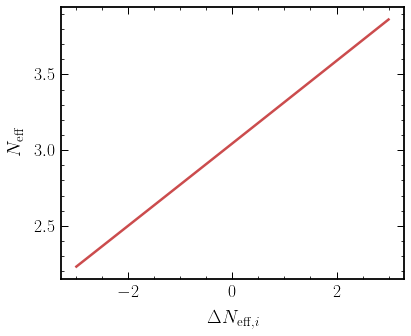

In [6]:
plt.plot(delta_neff_init_vals, Neffs)
plt.xlabel(r"$\Delta N_{\mathrm{eff},i}$")
plt.ylabel(r"$N_{\rm{eff}}$")

In new physics scenarios this relationship may change!  Since $N_{\rm{eff}}$ is output alongside the LINX thermodynamics calculation, we recommend storing `Neff_vec[-1]` as a derived parameter when doing analyses involving parameter estimation.  If you do not store this output and there is still a bijective map between `Delta_Neff_init` and $N_{\rm{eff}}$ in your cosmology, you can also build an interpolator after the fact and run your samples through it:

In [7]:
step = 0.1
input_dNeff = jnp.arange(-7.,7+step,step=step)
output_Neff = []
for dNeff in input_dNeff:
    t_vec, a_vec, rho_g_vec, rho_nu_vec, rho_extra_vec, P_extra_vec, Neff_vec = get_thermodynamics(dNeff)
    output_Neff.append(Neff_vec[-1])

In [8]:
Neff = interp1d(input_dNeff,output_Neff)

In [9]:
Neff(0.84)

array(3.27367812)